In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path


proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 4)
sys.path.append(proj_root)

print(proj_root)

d:\Work\repos\RL\phd-rl-algos


In [ ]:
import yaml
import torch
import numpy as np
import pandas as pd
import seaborn as sns

from opinion_dynamics.utils.my_logging import setup_logger
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.utils.experiment import instantiate_agent
from dynamic_programming.opinion_dynamics.common.viz import (
    interpolate_opinion_trajectory,
    plot_action_heatmap,
    plot_opinions_over_time,
)
from opinion_dynamics.baseline import (
    flatten_intermediate_states_np,
    run_policy_agent,
)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

from rl_envs_forge.envs.network_graph.network_graph import NetworkGraph
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import (
    run_policy,
    run_centrality_policy,
    flatten_intermediate_states_np,
)
from opinion_dynamics.experiments.algos import centrality_based_continuous_control

from dynamic_programming.opinion_dynamics.algos import (
    compute_average_error,
    compute_final_average_error,
    generate_full_control_policy,
    generate_control_from_vector,
)
from dynamic_programming.opinion_dynamics.algo_infinite_horizon import (
    value_iteration,
    extract_policy,
    create_state_grid,
)
from dynamic_programming.opinion_dynamics.common.viz import (
    plot_opinions_over_time,
    visualize_policy_from_env,
    plot_action_heatmap,
    interpolate_opinion_trajectory,
)

In [54]:
import contextlib
import matplotlib.pyplot as plt

@contextlib.contextmanager
def intercept_show(pre_show=None):
    """
    Temporarily wraps plt.show() so you can modify the current figure/axes
    right before it is displayed.
    """
    original_show = plt.show

    def wrapped_show(*args, **kwargs):
        if pre_show is not None:
            pre_show()
        return original_show(*args, **kwargs)

    plt.show = wrapped_show
    try:
        yield
    finally:
        plt.show = original_show


def apply_publication_style(
    *,
    grid: bool,
    grid_axis: str = "both",
    keep_line_colors: bool = True,
    force_black_edges: bool = True,
    # text sizes
    title_size: int = 22,
    label_size: int = 20,
    tick_size: int = 16,
    annotate_size: int = 20,
):
    fig = plt.gcf()
    fig.patch.set_facecolor("white")

    for ax in fig.get_axes():
        ax.set_facecolor("white")

        # Titles / axis labels
        ax.title.set_fontsize(title_size)
        ax.xaxis.label.set_fontsize(label_size)
        ax.yaxis.label.set_fontsize(label_size)

        # Tick label size
        ax.tick_params(axis="both", which="major", labelsize=tick_size, colors="black")

        # Spines / label colors
        for spine in ax.spines.values():
            spine.set_color("black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")

        # Grid
        ax.set_axisbelow(True)
        if grid:
            ax.grid(True, axis=grid_axis, which="major",
                    color="black", alpha=0.25, linewidth=0.8, linestyle="-")
        else:
            ax.grid(False)

        # Lines
        if not keep_line_colors:
            for line in ax.get_lines():
                line.set_color("black")

        # Patch edges
        if force_black_edges:
            for p in ax.patches:
                try:
                    p.set_edgecolor("black")
                    p.set_linewidth(1.0)
                except Exception:
                    pass

            for c in ax.collections:
                try:
                    c.set_edgecolor("black")
                except Exception:
                    pass

        # Annotation-like text (ax.text + network labels + heatmap annotations)
        protected = {ax.title, ax.xaxis.label, ax.yaxis.label}
        for t in ax.texts:
            if t not in protected:
                t.set_fontsize(annotate_size)
                t.set_color("black")

    # ---- NEW: handle seaborn heatmap colorbar (ticks/label) ----
    # Seaborn heatmap creates an additional Axes for the colorbar.
    # Matplotlib exposes them via fig.axes; we already looped them above,
    # but colorbar label is often stored on the Colorbar object, so also do:
    for cb in getattr(fig, "_colorbars", []):
        try:
            cb.ax.tick_params(labelsize=tick_size, colors="black")
            cb.ax.yaxis.label.set_fontsize(label_size)
            cb.ax.yaxis.label.set_color("black")
        except Exception:
            pass

    # More robust colorbar discovery:
    for ax in fig.get_axes():
        # if this axes looks like a colorbar axes (often has no x ticks and is skinny)
        # still safe: just re-apply tick size (done above) + try label sizing
        try:
            ax.yaxis.label.set_fontsize(label_size)
        except Exception:
            pass


def render_styled(
    env,
    mode="centralities",
    *,
    theme="bw",
    grid=False,
    # ---- NEW: default sizes requested ----
    title_size=22,
    label_size=20,
    tick_size=16,
    annotate_size=20,
    # other style toggles
    grid_axis="both",
    keep_line_colors=True,
    force_black_edges=True,
    **render_kwargs,
):
    """
    Wrap env.render() without modifying the package.

    Example:
      render_styled(env, mode="centralities", theme="bw", grid=True,
                    title_size=22, label_size=20, tick_size=16, annotate_size=20)

    Notes:
      - Sizes are applied right before plt.show().
      - Works for both network plots and seaborn/matplotlib plots.
    """
    if theme == "bw":
        with intercept_show(
            pre_show=lambda: apply_publication_style(
                grid=grid,
                grid_axis=grid_axis,
                keep_line_colors=keep_line_colors,
                force_black_edges=force_black_edges,
                title_size=title_size,
                label_size=label_size,
                tick_size=tick_size,
                annotate_size=annotate_size,
            )
        ):
            return env.render(mode=mode, **render_kwargs)
    else:
        return env.render(mode=mode, **render_kwargs)

2026-02-06 23:00:12,196 - dqn - INFO - opinion_py:139 - asserts_enabled=True, optimize=0, PYTHONOPTIMIZE=None
2026-02-06 23:00:12,197 - dqn - INFO - opinion_py:372 - [CFG] Using SOFT updates with tau=0.0001.
2026-02-06 23:00:12,200 - dqn - INFO - opinion_py:391 - Loaded configuration settings.
2026-02-06 23:00:12,203 - dqn - INFO - opinion_py:627 - [CFG] LR scheduler: CosineAnnealingWarmRestarts(T_0=300000, T_mult=2, eta_min=5e-06)
2026-02-06 23:00:12,203 - dqn - INFO - opinion_py:672 - [INIT] Model config: {'model_class': 'OpinionNet', 'nr_agents': 20, 'nr_betas': 3, 'lin_hidden_size': 128, 'softplus_beta': 1.0, 'wstar_eps': 1e-06, 'A_min': 0.01, 'A_max': 3, 'b_tanh_scale': None, 'c_tanh_scale': None} | Optimizer: {'optim_class': 'Adam', 'lr': 3e-05, 'betas': [0.9, 0.999], 'eps': 1e-06, 'weight_decay': 0} | params: total=35323, trainable=35323
2026-02-06 23:00:12,203 - dqn - INFO - opinion_py:636 - Initialized networks and optimizer.
2026-02-06 23:00:12,654 - dqn - INFO - opinion_py:7

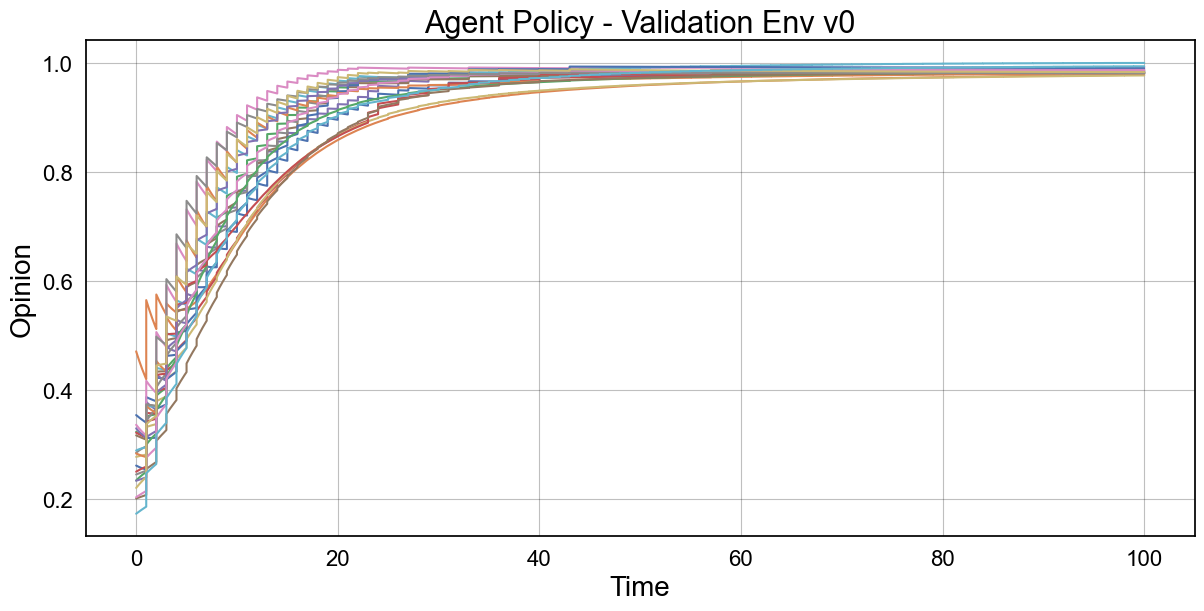

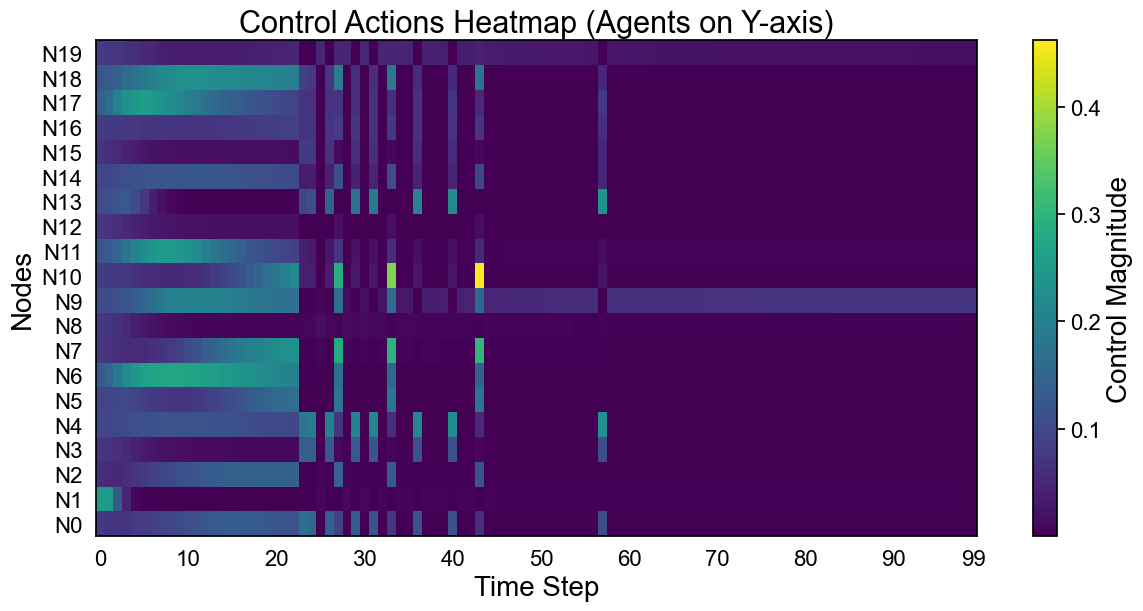

Total discounted reward: -8.3936

--- Running agent on validation environment version 1 ---
Simulation ended at step 99: done=False, truncated=True


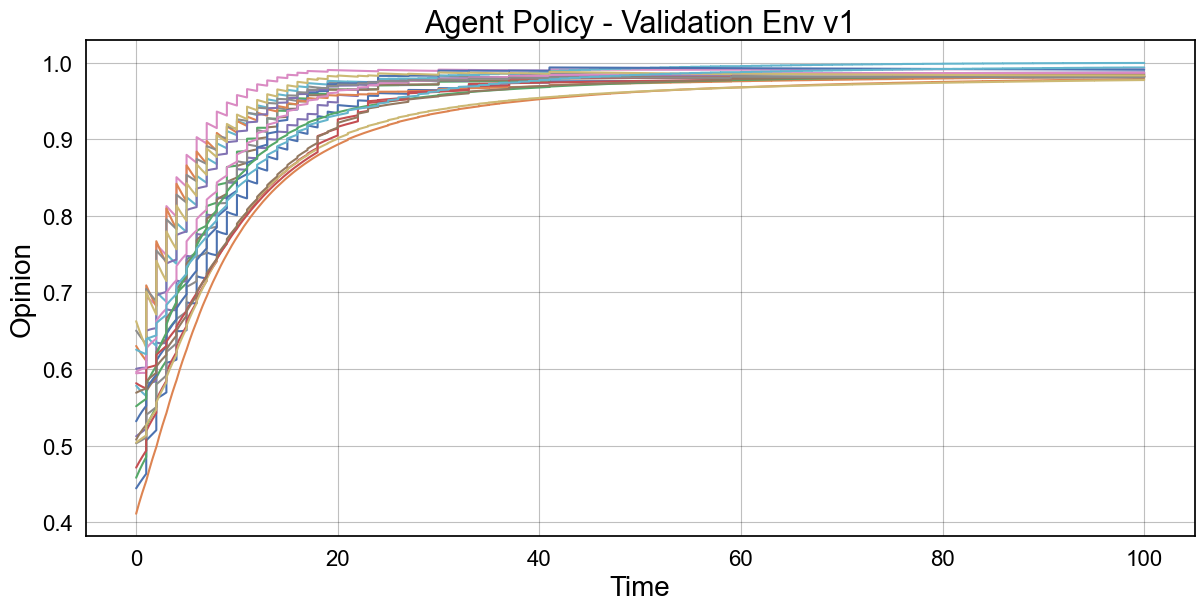

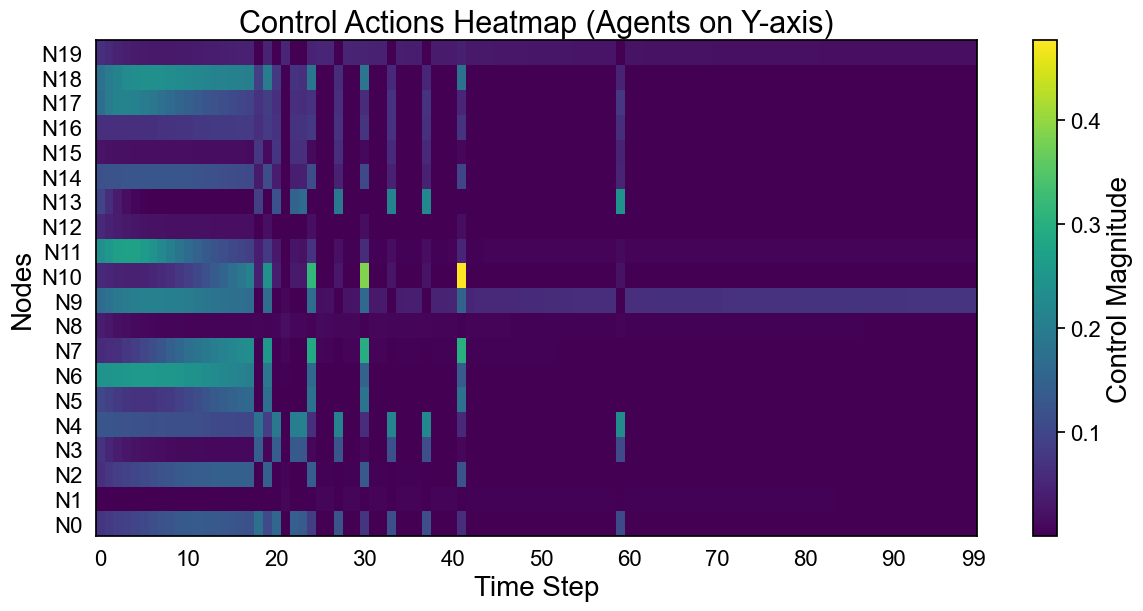

Total discounted reward: -5.8634

--- Running agent on validation environment version 2 ---
Simulation ended at step 99: done=False, truncated=True


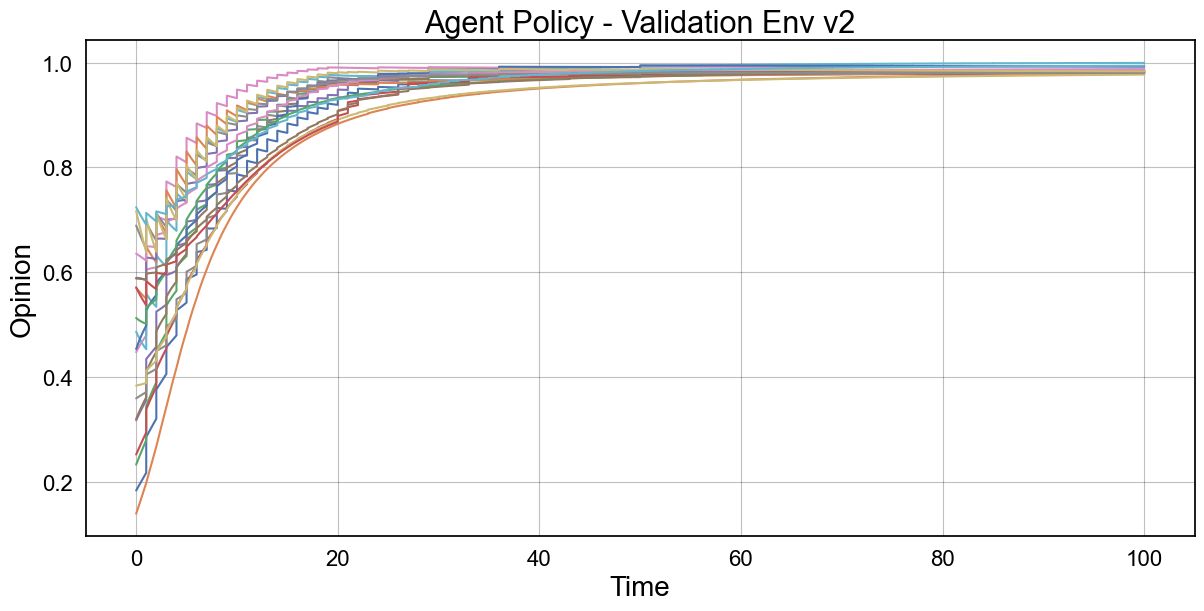

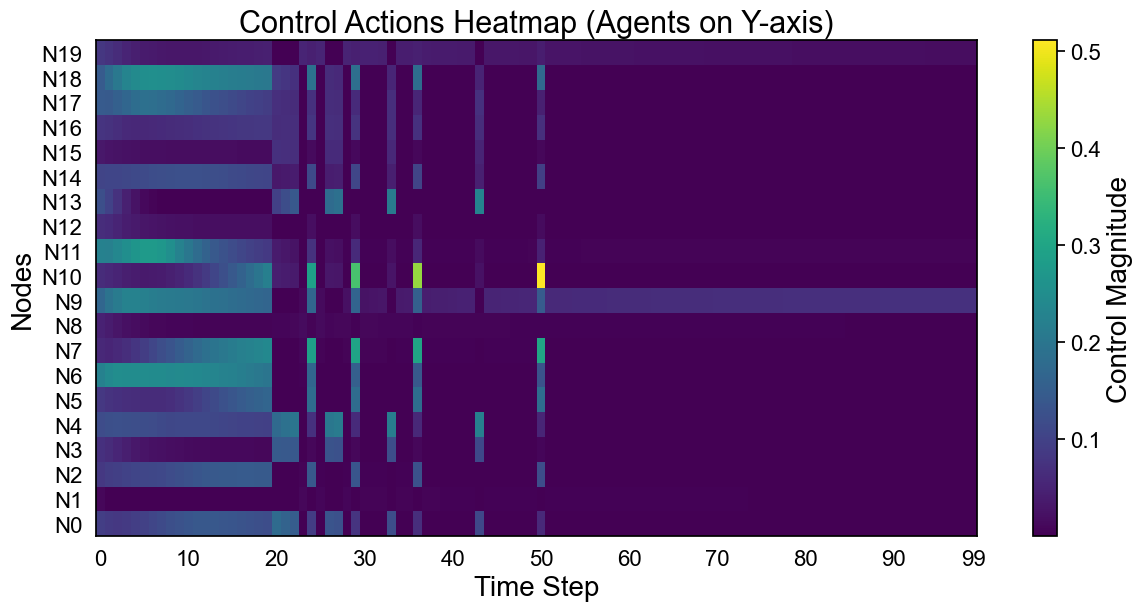

Total discounted reward: -6.6223
   version  discounted_reward
0        0          -8.393591
1        1          -5.863394
2        2          -6.622331


In [55]:
# exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Sep11-034202_configs\0000_optim.args_.lr_1e-05__agent_params.args_.betas__0__1__2___agent_params.model_OpinionNetCommonAB__experiment_opinion_agent_dqn_fixed_steps\2"
# exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Sep15-090310_configs\0000_optim.args_.lr_1e-05__agent_params.args_.betas__0__1__2___agent_params.model_OpinionNetCommonAB__experiment_opinion_agent_dqn_fixed_steps\1"
# exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Oct27-022212_configs\0002_estimator.args_.c_tanh_scale_None__optim.args_.lr_3e-05__agent_params.args_.target_soft_tau_0.0001__experiment_fixed_res\0"
# exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Oct28-115156_configs\0000_optim.args_.lr_1e-05__agent_params.args_.target_soft_tau_0.0001__experiment_fixed_res\1"
# exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Oct29-151336_configs\0000_optim.args_.lr_1e-05__agent_params.args_.target_soft_tau_0.0001__experiment_fixed_res\0"
# exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Oct31-115130_configs\0002_optim.args_.lr_3e-05__agent_params.args_.target_soft_tau_0.0001__experiment_fixed_res\0"
exp_subdir = r"d:\Work\repos\RL\phd-rl-algos\dqn\opinion_dynamics\experiments\results\2025Oct30-234652_configs\0002_optim.args_.lr_3e-05__agent_params.args_.target_soft_tau_0.0001__experiment_fixed_res\1"

checkpoint = 35
# checkpoint = None

agent = instantiate_agent(exp_subdir, checkpoint)

results = []
df_actions_list = []

env_versions = agent.env_factory.validation_versions
# env_versions = [0]

for version in range(len(env_versions)):
    print(f"\n--- Running agent on validation environment version {version} ---")

    # Force environment to version
    agent.validation_env = agent.env_factory.get_validation_env(version=version)

    # Run policy with agent
    states, times, rewards, actions, all_intermediate_states = run_policy_agent(agent)

    actions_np = np.asarray(actions)  # shape (T, N)
    T, N = actions_np.shape[0], actions_np.shape[1]

    df_actions_v = pd.DataFrame(actions_np, columns=[f"a_{j}" for j in range(N)])
    df_actions_v.insert(0, "t_idx", np.arange(T))
    df_actions_v.insert(0, "version", version)

    df_actions_list.append(df_actions_v)

    flat_states, flat_times = flatten_intermediate_states_np(
        all_intermediate_states,
        agent.validation_env.t_campaign,
        agent.validation_env.t_s,
    )
    # plot_opinions_over_time(
    #     flat_states, flat_times, title=f"Agent Policy - Validation Env v{version}"
    # )
    with intercept_show(
        pre_show=lambda: apply_publication_style(
            grid=True,
            grid_axis="both",
            keep_line_colors=True,  # <-- key
            force_black_edges=False,  # lines already have colors; no need to mess with collections
        )
    ):
        plot_opinions_over_time(
            flat_states, flat_times, title=f"Agent Policy - Validation Env v{version}"
        )
    
    with intercept_show(
        pre_show=lambda: apply_publication_style(
            grid=False,
            keep_line_colors=True,
            force_black_edges=False,
            title_size=22,
            label_size=20,
            tick_size=16,
            annotate_size=20,
        )
    ):
        plot_action_heatmap(actions)

    total_value = sum((agent.gamma**i) * r for i, r in enumerate(rewards))
    print(f"Total discounted reward: {total_value:.4f}")
    results.append({"version": version, "discounted_reward": total_value})

# Per-version results (unchanged)
df_results_agent = pd.DataFrame(results)
print(df_results_agent)

In [56]:
def build_budget_schedule_from_df(
    df_actions: pd.DataFrame, version: int, num_steps: int, fill: float = 0.0
) -> np.ndarray:
    """
    From df_actions (columns: version, t_idx, a_0..a_{N-1}), build a length `num_steps`
    vector of per-step budgets for the given version.
    """
    df_v = df_actions[df_actions["version"] == version].sort_values("t_idx")
    if df_v.empty:
        return np.zeros(num_steps, dtype=float)

    action_cols = [c for c in df_v.columns if c.startswith("a_")]
    s = df_v[action_cols].sum(axis=1).to_numpy(dtype=float)  # per-step sum (mass)

    # clean + size to match num_steps
    s = np.clip(np.nan_to_num(s, nan=fill), 0.0, None)
    if len(s) >= num_steps:
        s = s[:num_steps]
    else:
        s = np.pad(s, (0, num_steps - len(s)), mode="constant", constant_values=fill)
    return s


def run_uniform_policy_with_schedule(env, budget_schedule: np.ndarray, max_steps: int):
    """
    Runs a uniform broadcast where at step t each node gets b_t / N,
    with b_t from `budget_schedule`.
    Returns (opinions_over_time, time_points, rewards, actions, intermediary_states).
    """
    s, info = env.reset()
    opinions_over_time = [np.array(s, copy=True)]
    time_points, rewards, actions, intermediary_states = [], [], [], []
    is_terminated = False
    truncated = False
    N = env.num_agents

    for t, b_t in enumerate(budget_schedule[:max_steps]):
        u_t = np.full(N, float(b_t) / N, dtype=float)

        s_next, r, is_terminated, truncated, info = env.step(u_t)

        opinions_over_time.append(np.array(s_next, copy=True))
        actions.append(np.array(u_t, copy=True))
        rewards.append(float(r))
        time_points.append(float(getattr(env, "t_current", t)))

        inter = info.get("intermediate_states") if isinstance(info, dict) else None
        intermediary_states.append(inter)

        if is_terminated or truncated:
            break

    return (
        np.asarray(opinions_over_time),
        np.asarray(time_points),
        rewards,
        actions,
        intermediary_states,
    )


def run_centrality_policy_with_schedule(
    env, budget_schedule: np.ndarray, max_steps: int
):
    """
    Runs centrality step-by-step using a provided per-step budget schedule.
    Returns (opinions_over_time, time_points, rewards, actions, intermediary_states)
    to match your current usage.
    """
    s, info = env.reset()
    opinions_over_time = [np.array(s, copy=True)]
    time_points, rewards, actions, intermediary_states = [], [], [], []
    is_terminated = False
    truncated = False

    for t, b_t in enumerate(budget_schedule[:max_steps]):
        u_t, _ = centrality_based_continuous_control(env, available_budget=float(b_t))
        s_next, r, is_terminated, truncated, info = env.step(u_t)

        opinions_over_time.append(np.array(s_next, copy=True))
        actions.append(np.array(u_t, copy=True))
        rewards.append(float(r))
        time_points.append(float(getattr(env, "t_current", t)))

        inter = info.get("intermediate_states") if isinstance(info, dict) else None
        intermediary_states.append(inter)

        if is_terminated or truncated:
            break

    return (
        np.asarray(opinions_over_time),
        np.asarray(time_points),
        rewards,
        actions,
        intermediary_states,
    )


--- Running UNIFORM (matched budgets) for validation environment version 0 ---


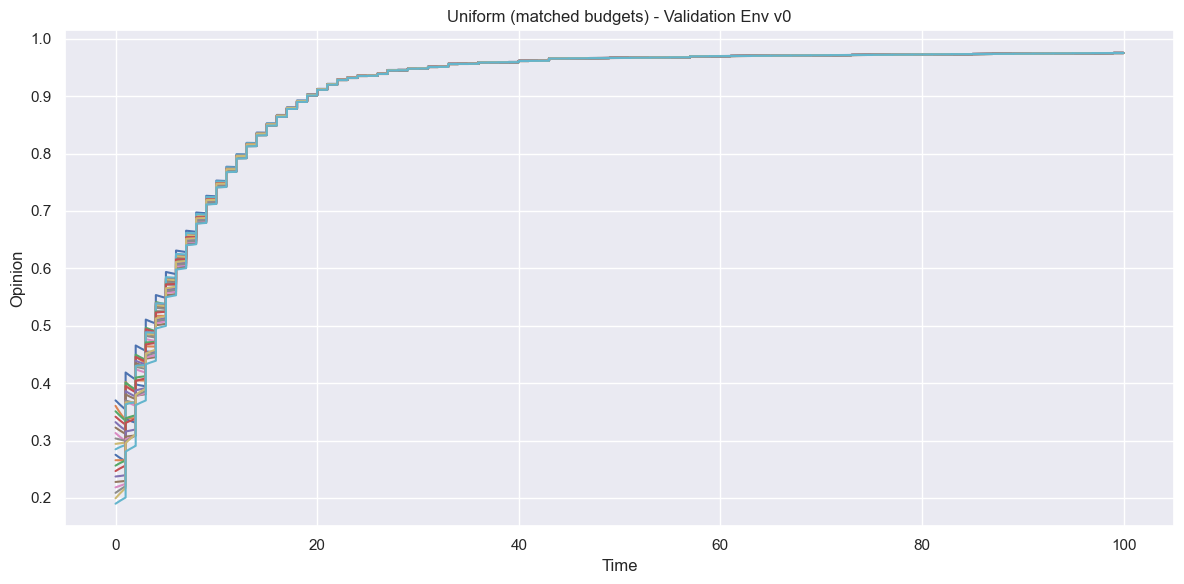

Total discounted reward (uniform matched): -9.3132

--- Running UNIFORM (matched budgets) for validation environment version 1 ---


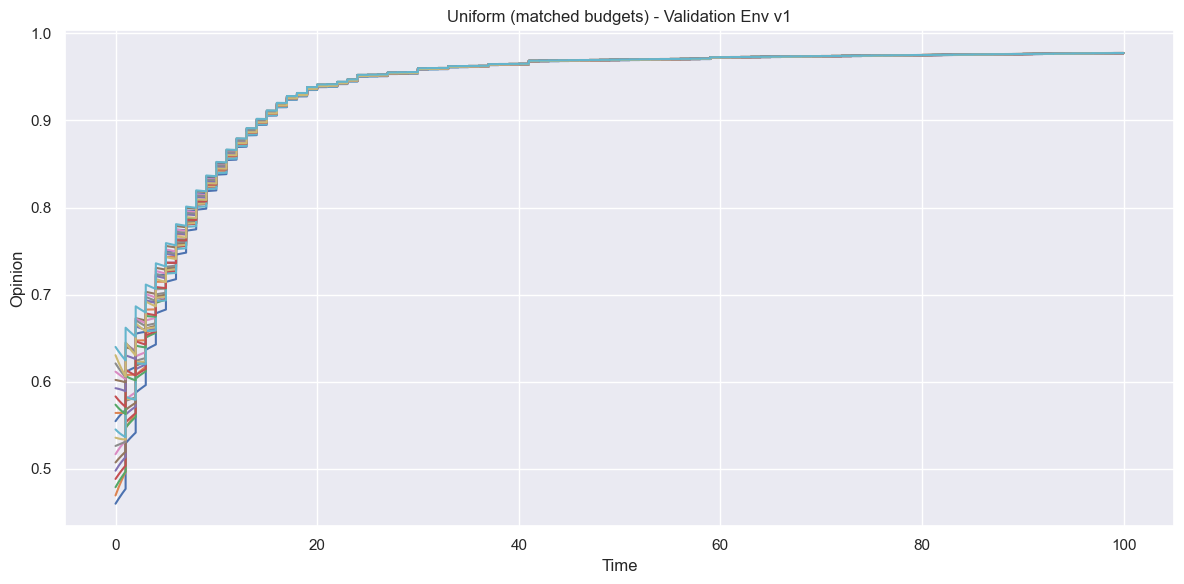

Total discounted reward (uniform matched): -6.6075

--- Running UNIFORM (matched budgets) for validation environment version 2 ---


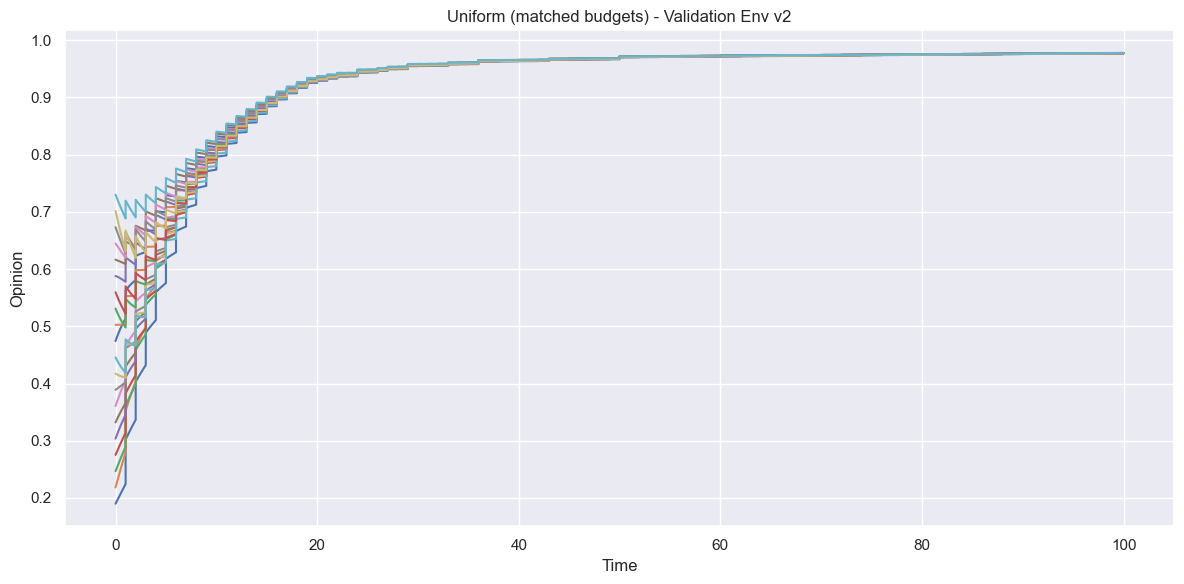

Total discounted reward (uniform matched): -7.3842
   version  discounted_reward
0        0          -9.313204
1        1          -6.607524
2        2          -7.384210


In [57]:
factory = agent.env_factory
gamma = agent.gamma

# concat all per-version action frames you collected earlier
df_actions = pd.concat(df_actions_list, ignore_index=True)

results_uniform = []

for version in range(len(factory.validation_versions)):
    print(
        f"\n--- Running UNIFORM (matched budgets) for validation environment version {version} ---"
    )
    env = factory.get_validation_env(version=version)
    num_steps = env.max_steps  # per-env is safest

    # Build per-step budget schedule by filtering df_actions inside the builder
    budget_schedule = build_budget_schedule_from_df(
        df_actions, version=version, num_steps=num_steps, fill=0.0
    )
    # budget_schedule = np.ones(num_steps, dtype=float) * 2.0

    # (optional) quick sanity print
    # print(
    #     f"[sched] v={version} | len={len(budget_schedule)} "
    #     f"| sum={budget_schedule.sum():.3f} | head={budget_schedule[:5]}"
    # )

    # Run uniform broadcast with that schedule
    opinions_over_time, time_points, rewards, actions, intermediary_states = (
        run_uniform_policy_with_schedule(
            env, budget_schedule=budget_schedule, max_steps=num_steps
        )
    )

    # Plot like before
    flat_states, flat_times = flatten_intermediate_states_np(
        intermediary_states, env.t_campaign, env.t_s
    )
    plot_opinions_over_time(
        flat_states,
        flat_times,
        title=f"Uniform (matched budgets) - Validation Env v{version}",
    )

    total_value = sum((gamma**i) * r for i, r in enumerate(rewards))
    print(f"Total discounted reward (uniform matched): {total_value:.4f}")
    results_uniform.append({"version": version, "discounted_reward": total_value})

df_results_uniform = pd.DataFrame(results_uniform)
print(df_results_uniform)


--- Running UNIFORM (full budget) for validation environment version 0 ---


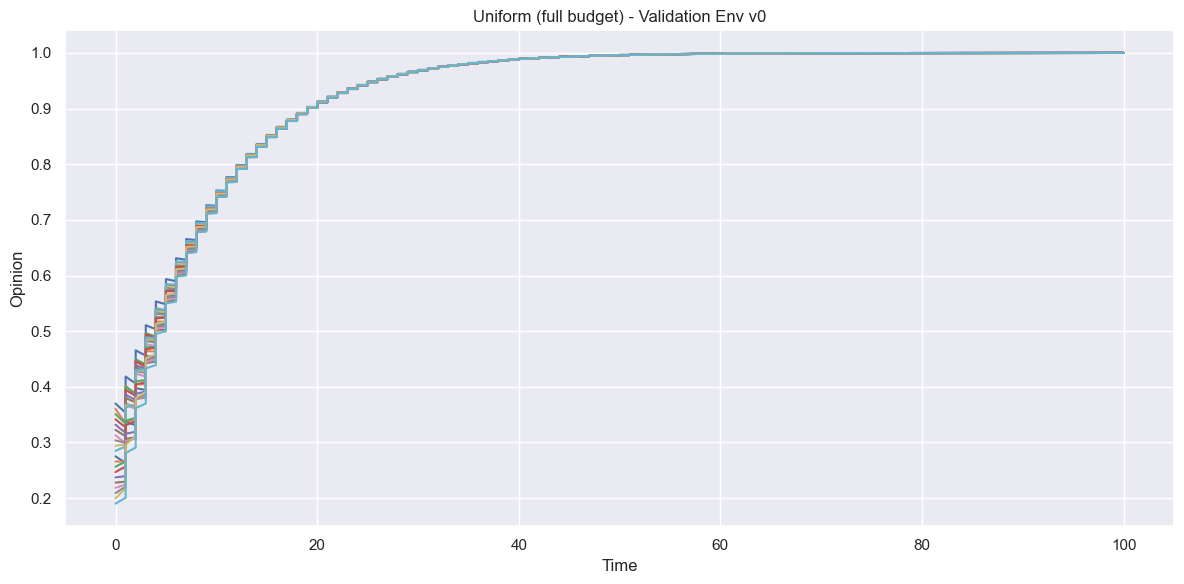

Total discounted reward (uniform full budget): -10.3880

--- Running UNIFORM (full budget) for validation environment version 1 ---


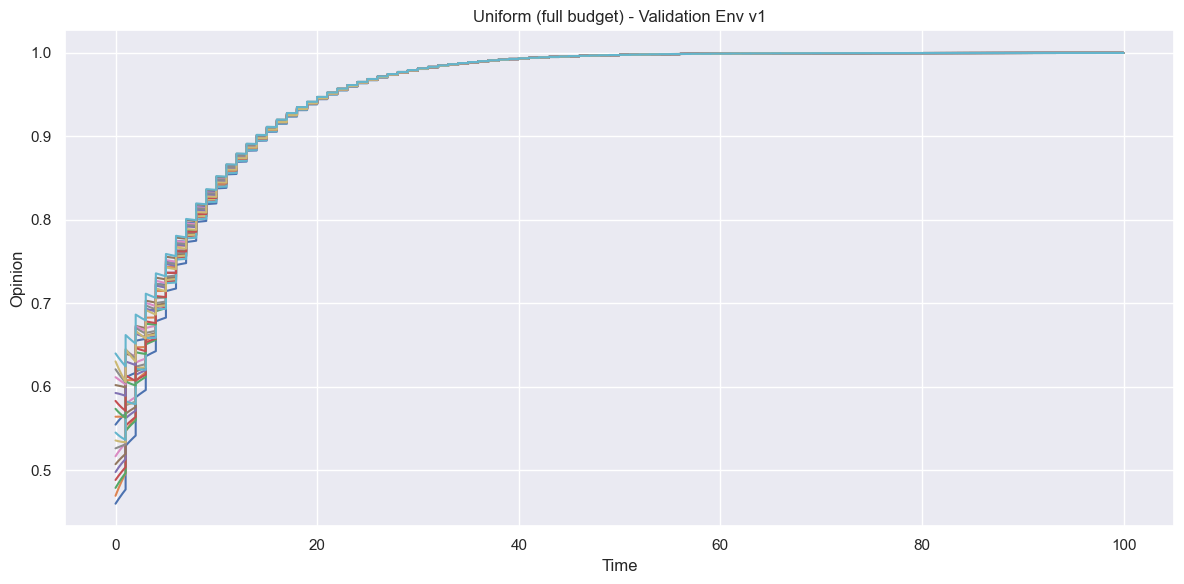

Total discounted reward (uniform full budget): -7.8413

--- Running UNIFORM (full budget) for validation environment version 2 ---


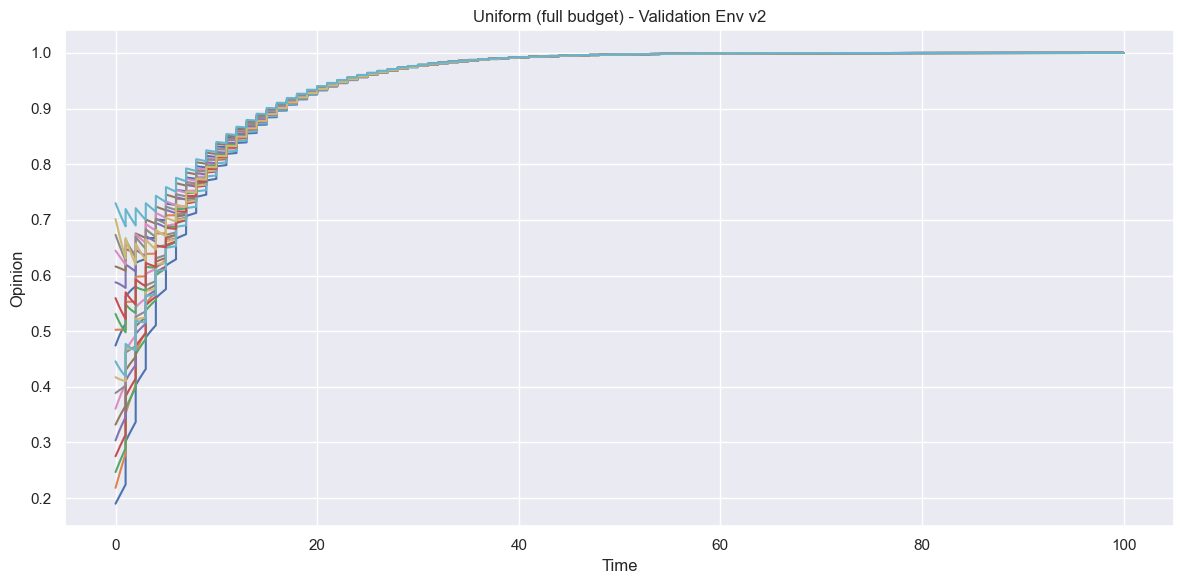

Total discounted reward (uniform full budget): -8.5785
   version  discounted_reward
0        0         -10.387989
1        1          -7.841260
2        2          -8.578465


In [58]:
factory = agent.env_factory
gamma = agent.gamma

# concat all per-version action frames you collected earlier
df_actions = pd.concat(df_actions_list, ignore_index=True)

results_uniform_full = []

for version in range(len(factory.validation_versions)):
    print(
        f"\n--- Running UNIFORM (full budget) for validation environment version {version} ---"
    )
    env = factory.get_validation_env(version=version)
    num_steps = env.max_steps  # per-env is safest

    # Build per-step budget schedule by filtering df_actions inside the builder
    # budget_schedule = build_budget_schedule_from_df(
    #     df_actions, version=version, num_steps=num_steps, fill=0.0
    # )
    budget_schedule = np.ones(num_steps, dtype=float) * 2.0

    # (optional) quick sanity print
    # print(
    #     f"[sched] v={version} | len={len(budget_schedule)} "
    #     f"| sum={budget_schedule.sum():.3f} | head={budget_schedule[:5]}"
    # )

    # Run uniform broadcast with that schedule
    opinions_over_time, time_points, rewards, actions, intermediary_states = (
        run_uniform_policy_with_schedule(
            env, budget_schedule=budget_schedule, max_steps=num_steps
        )
    )

    # Plot like before
    flat_states, flat_times = flatten_intermediate_states_np(
        intermediary_states, env.t_campaign, env.t_s
    )
    plot_opinions_over_time(
        flat_states,
        flat_times,
        title=f"Uniform (full budget) - Validation Env v{version}",
    )

    total_value = sum((gamma**i) * r for i, r in enumerate(rewards))
    print(f"Total discounted reward (uniform full budget): {total_value:.4f}")
    results_uniform_full.append({"version": version, "discounted_reward": total_value})

df_results_uniform_full = pd.DataFrame(results_uniform_full)
print(df_results_uniform_full)


--- Running centrality policy for validation environment version 0 ---


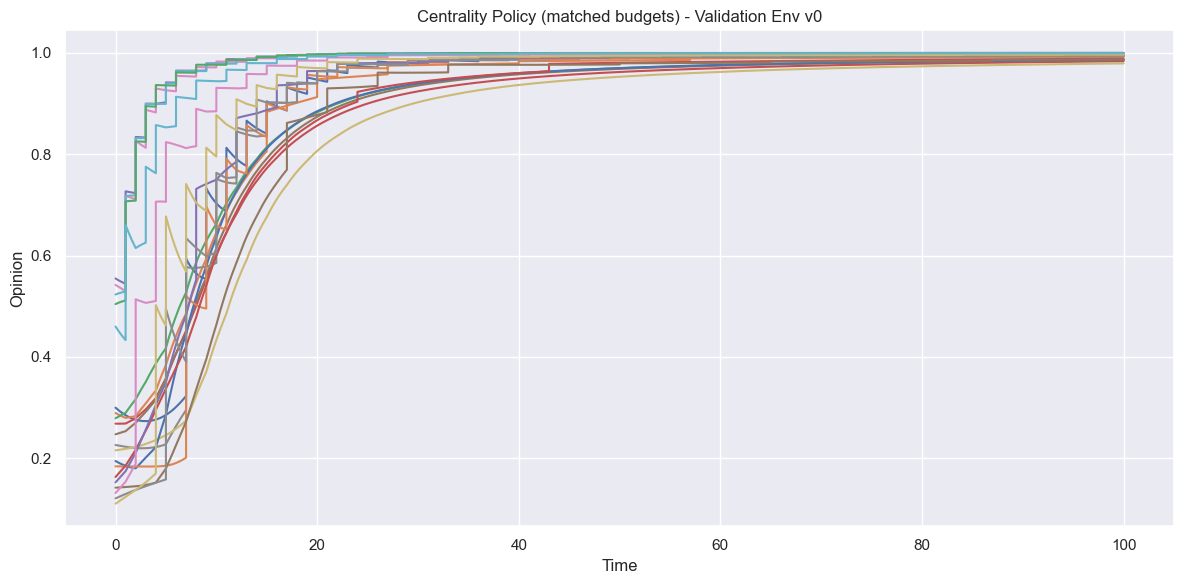

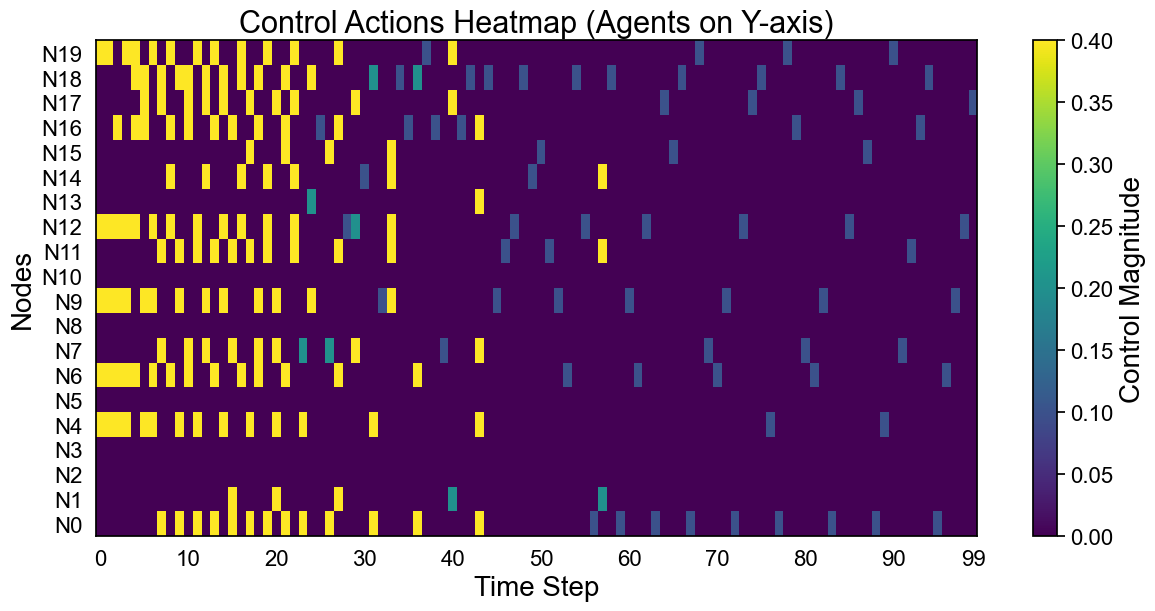

Total discounted reward: -8.3852

--- Running centrality policy for validation environment version 1 ---


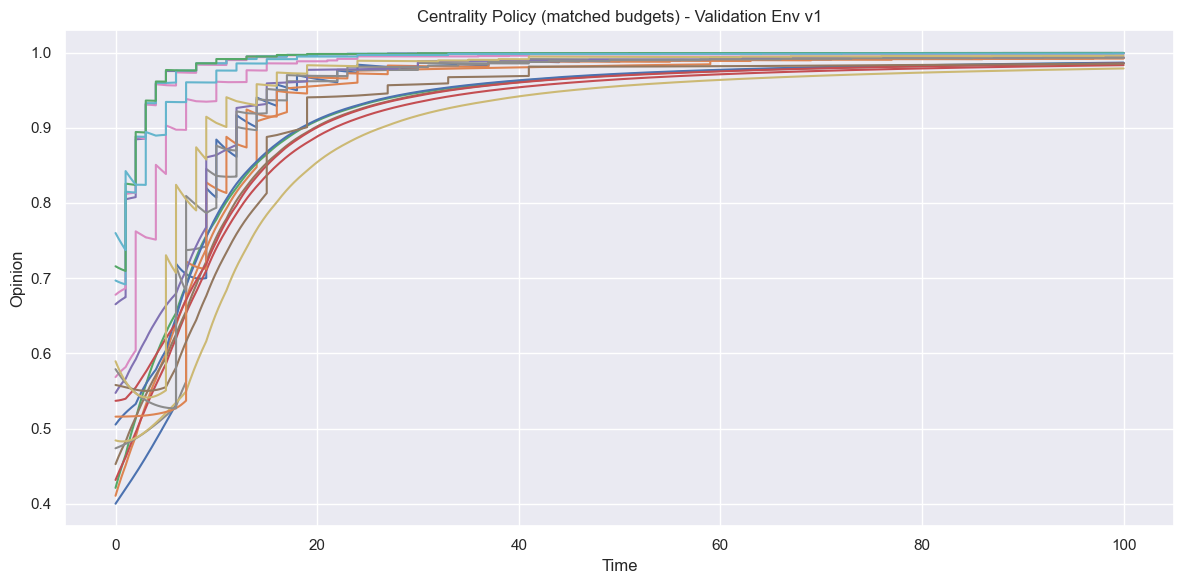

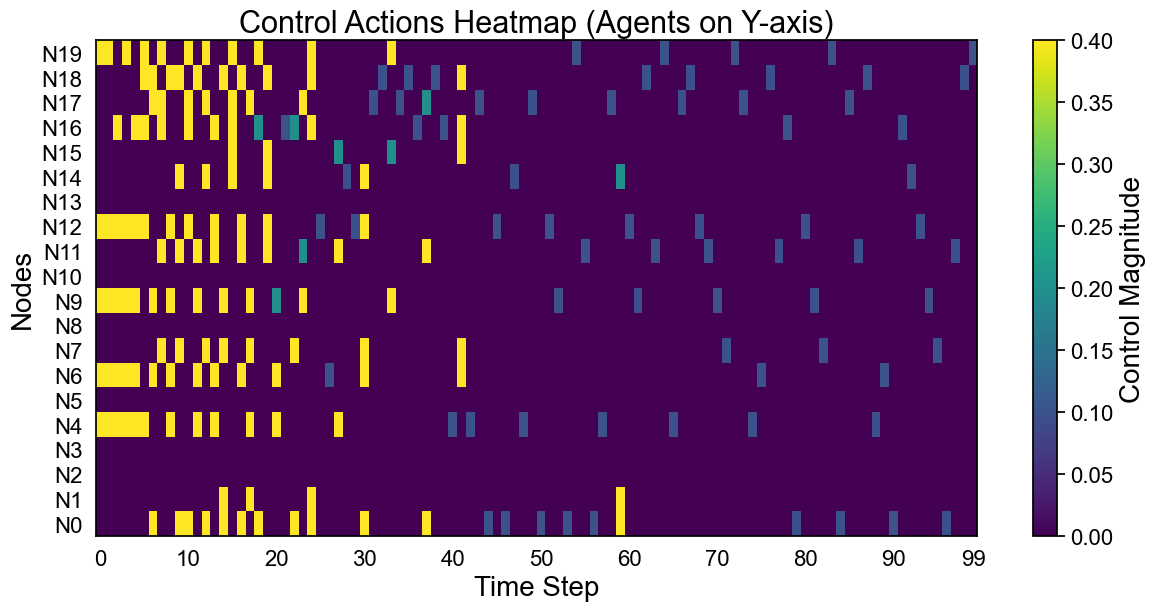

Total discounted reward: -5.8543

--- Running centrality policy for validation environment version 2 ---


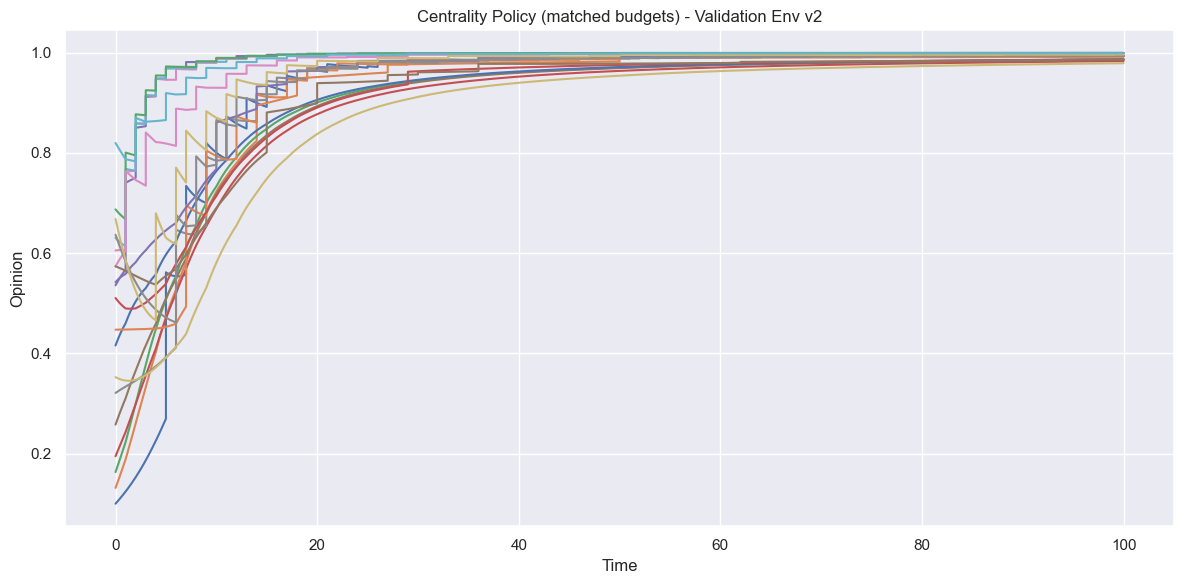

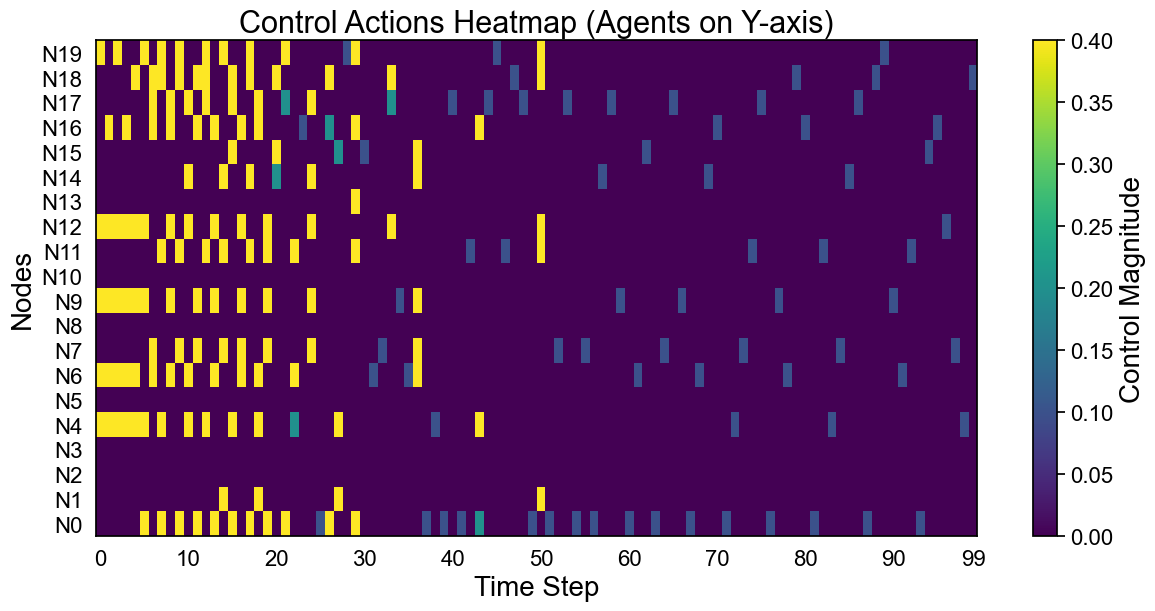

Total discounted reward: -6.5856
   version  discounted_reward
0        0          -8.385193
1        1          -5.854295
2        2          -6.585630


In [59]:
# --- Parameters ---
gamma = agent.gamma

factory = agent.env_factory
results = []

env_versions = factory.validation_versions
# env_versions = [0]

# Ensure df_actions exists (from your agent run):
df_actions = pd.concat(df_actions_list, ignore_index=True)

for version in range(len(env_versions)):
    print(
        f"\n--- Running centrality policy for validation environment version {version} ---"
    )
    env = factory.get_validation_env(version=version)

    # NEW: build per-step budget schedule from the agent’s actions
    budget_schedule = build_budget_schedule_from_df(
        df_actions, version=version, num_steps=num_steps, fill=0.0
    )
    # budget_schedule = np.ones(len(df_actions_v)) * 2

    # NEW: run centrality with the schedule
    opinions_over_time, time_points, rewards, actions, intermediary_states = (
        run_centrality_policy_with_schedule(
            env, budget_schedule=budget_schedule, max_steps=num_steps
        )
    )

    flat_states, flat_times = flatten_intermediate_states_np(
        intermediary_states, env.t_campaign, env.t_s
    )
    
    plot_opinions_over_time(
        flat_states,
        flat_times,
        title=f"Centrality Policy (matched budgets) - Validation Env v{version}",
    )
    with intercept_show(
        pre_show=lambda: apply_publication_style(
            grid=False,
            keep_line_colors=True,
            force_black_edges=False,
            title_size=22,
            label_size=20,
            tick_size=16,
            annotate_size=20,
        )
    ):
        plot_action_heatmap(actions)
        

    total_value = sum((gamma**i) * r for i, r in enumerate(rewards))
    print(f"Total discounted reward: {total_value:.4f}")
    results.append({"version": version, "discounted_reward": total_value})

df_results_centrality = pd.DataFrame(results)
print(df_results_centrality)

In [60]:
# plot_action_heatmap(actions)

In [61]:
for df in (
    df_results_agent,
    df_results_centrality,
    df_results_uniform,
    df_results_uniform_full,
):
    df["version"] = df["version"].astype(int)

df_compare = (
    df_results_agent.rename(columns={"discounted_reward": "agent"})
    .merge(
        df_results_centrality.rename(columns={"discounted_reward": "centrality"}),
        on="version",
        how="outer",
    )
    .merge(
        df_results_uniform.rename(columns={"discounted_reward": "uniform"}),
        on="version",
        how="outer",
    )
    .merge(
        df_results_uniform_full.rename(columns={"discounted_reward": "uniform_full"}),
        on="version",
        how="outer",
    )
    .sort_values("version")
    .reset_index(drop=True)
)

print(df_compare)

   version     agent  centrality   uniform  uniform_full
0        0 -8.393591   -8.385193 -9.313204    -10.387989
1        1 -5.863394   -5.854295 -6.607524     -7.841260
2        2 -6.622331   -6.585630 -7.384210     -8.578465
